# Multi-Class Image Classifier with NumPy and Adam

This notebook trains a NumPy-only MLP on the `Train/` dataset, evaluates on `Test/` when labels are available, and prints predictions for the test images.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

np.random.seed(42)

## 2. Dataset Loading

In [2]:
tr_p = Path("Train")
te_p = Path("Test")
sz = (64, 64)
lr = 1e-3
ep = 15
bs = 64
wd = 1e-4
ext = {".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp"}

try:
    rs = Image.Resampling.BILINEAR
except AttributeError:
    rs = Image.BILINEAR

In [3]:
def prep(fp, sz=sz):
    with Image.open(fp) as img:
        img = img.convert("RGB").resize(sz, rs)
        x = np.asarray(img, dtype=np.float32) / 255.0
    return x.reshape(-1)


def ld(p, cls=None, lab=True):
    p = Path(p)
    if not p.exists():
        raise FileNotFoundError(f"Missing folder: {p}")

    ds = sorted([d for d in p.iterdir() if d.is_dir()])
    ims = sorted([f for f in p.iterdir() if f.is_file() and f.suffix.lower() in ext])
    xs, ys, fs = [], [], []

    use_lab = lab is True
    if lab == "auto":
        use_lab = bool(ds) and not ims and cls is not None and all(d.name in cls for d in ds)

    if use_lab:
        if cls is None:
            cls = [d.name for d in ds]
        cm = {k: i for i, k in enumerate(cls)}
        for d in ds:
            if d.name not in cm:
                continue
            for f in sorted(d.rglob("*")):
                if f.is_file() and f.suffix.lower() in ext:
                    xs.append(prep(f))
                    ys.append(cm[d.name])
                    fs.append(str(f.relative_to(p)))
        X = np.asarray(xs, dtype=np.float32)
        y = np.asarray(ys, dtype=np.int64)
        return X, y, fs, cls, True

    for f in sorted(p.rglob("*")):
        if f.is_file() and f.suffix.lower() in ext:
            xs.append(prep(f))
            fs.append(str(f.relative_to(p)))
    X = np.asarray(xs, dtype=np.float32)
    if cls is None:
        cls = []
    return X, None, fs, cls, False


X0, y, tr_f, cls, _ = ld(tr_p, lab=True)
if X0.size == 0:
    raise ValueError("No training images found in Train/.")

Xt0, yt, te_f, _, te_lab = ld(te_p, cls=cls, lab="auto")

print("classes:", cls)
print("train shape:", X0.shape)
print("train labels:", y.shape)
print("test shape:", Xt0.shape)
print("test labeled:", te_lab)

classes: ['Jade', 'James', 'Jane', 'Joel', 'Jovi']
train shape: (4000, 12288)
train labels: (4000,)
test shape: (1000, 12288)
test labeled: True


## 3. Preprocessing

In [4]:
def ohe(y, c):
    Y = np.zeros((y.size, c), dtype=np.float32)
    Y[np.arange(y.size), y] = 1.0
    return Y


mu = X0.mean(axis=0, keepdims=True).astype(np.float32)
sd = X0.std(axis=0, keepdims=True).astype(np.float32)
X = np.ascontiguousarray(((X0 - mu) / (sd + 1e-8)).astype(np.float32))
if Xt0.ndim == 2 and Xt0.shape[0] > 0:
    Xt = np.ascontiguousarray(((Xt0 - mu) / (sd + 1e-8)).astype(np.float32))
else:
    Xt = np.empty((0, X.shape[1]), dtype=np.float32)
Y = ohe(y, len(cls))

print("X:", X.shape)
print("Y:", Y.shape)
print("Xt:", Xt.shape)

X: (4000, 12288)
Y: (4000, 5)
Xt: (1000, 12288)


## 4. Model Functions

In [5]:
def init_p(n0, n1, n2, n3):
    p = {
        "W1": (np.random.randn(n0, n1).astype(np.float32) * np.sqrt(2.0 / n0)).astype(np.float32),
        "b1": np.zeros((1, n1), dtype=np.float32),
        "W2": (np.random.randn(n1, n2).astype(np.float32) * np.sqrt(2.0 / n1)).astype(np.float32),
        "b2": np.zeros((1, n2), dtype=np.float32),
        "W3": (np.random.randn(n2, n3).astype(np.float32) * np.sqrt(2.0 / n2)).astype(np.float32),
        "b3": np.zeros((1, n3), dtype=np.float32),
    }
    o = {"t": 0}
    for k in p:
        o["m" + k] = np.zeros_like(p[k])
        o["v" + k] = np.zeros_like(p[k])
    return p, o


def relu(z):
    return np.maximum(0.0, z)


def sm(z):
    z = z - np.max(z, axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)


def fwd(X, p):
    Z1 = X @ p["W1"] + p["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ p["W2"] + p["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ p["W3"] + p["b3"]
    A3 = sm(Z3)
    c = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, c


def loss(A3, Y):
    return -np.mean(np.sum(Y * np.log(A3 + 1e-9), axis=1))


def bwd(X, Y, p, c):
    m = X.shape[0]
    d3 = (c["A3"] - Y) / m
    dW3 = c["A2"].T @ d3
    db3 = np.sum(d3, axis=0, keepdims=True)

    d2 = d3 @ p["W3"].T
    d2 = d2 * (c["Z2"] > 0)
    dW2 = c["A1"].T @ d2
    db2 = np.sum(d2, axis=0, keepdims=True)

    d1 = d2 @ p["W2"].T
    d1 = d1 * (c["Z1"] > 0)
    dW1 = X.T @ d1
    db1 = np.sum(d1, axis=0, keepdims=True)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}


def upd(p, g, o, lr, wd, b1=0.9, b2=0.999, eps=1e-8):
    o["t"] += 1
    t = o["t"]
    for k in p:
        gg = g[k]
        if k.startswith("W"):
            gg = gg + wd * p[k]
        o["m" + k] = b1 * o["m" + k] + (1.0 - b1) * gg
        o["v" + k] = b2 * o["v" + k] + (1.0 - b2) * (gg * gg)
        mh = o["m" + k] / (1.0 - b1 ** t)
        vh = o["v" + k] / (1.0 - b2 ** t)
        p[k] -= lr * mh / (np.sqrt(vh) + eps)
    return p, o


def pred(X, p):
    A3, _ = fwd(X, p)
    return np.argmax(A3, axis=1)


def cmat(yt, yp, c):
    cm = np.zeros((c, c), dtype=np.int64)
    for a, b in zip(yt, yp):
        cm[a, b] += 1
    return cm


def auc1(y, s):
    y = np.asarray(y, dtype=np.int64)
    n1 = int(np.sum(y))
    n0 = int(y.size - n1)
    if n1 == 0 or n0 == 0:
        return np.nan
    o = np.argsort(s, kind="mergesort")
    ss = s[o]
    yy = y[o]
    r = np.arange(1, y.size + 1, dtype=np.float64)
    i = 0
    while i < y.size:
        j = i + 1
        while j < y.size and ss[j] == ss[i]:
            j += 1
        r[i:j] = 0.5 * ((i + 1) + j)
        i = j
    sr = np.sum(r[yy == 1])
    return (sr - n1 * (n1 + 1) / 2.0) / (n1 * n0)


def auc_mc(Y, P):
    av = []
    wt = []
    sp = np.sum(Y, axis=0).astype(np.float64)
    for i in range(Y.shape[1]):
        a = auc1(Y[:, i], P[:, i])
        if not np.isnan(a):
            av.append(a)
            wt.append(sp[i])
    if len(av) == 0:
        return np.nan, np.nan
    av = np.asarray(av, dtype=np.float64)
    wt = np.asarray(wt, dtype=np.float64)
    return float(np.mean(av)), float(np.sum(av * wt) / np.sum(wt))


def metr(yt, yp, P, c):
    cm = cmat(yt, yp, c).astype(np.float64)
    tp = np.diag(cm)
    fp = np.sum(cm, axis=0) - tp
    fn = np.sum(cm, axis=1) - tp
    sp = np.sum(cm, axis=1)
    pr = tp / np.maximum(tp + fp, 1e-9)
    rc = tp / np.maximum(tp + fn, 1e-9)
    f1 = 2.0 * pr * rc / np.maximum(pr + rc, 1e-9)
    wg = sp / np.maximum(np.sum(sp), 1e-9)
    Y1 = ohe(np.asarray(yt, dtype=np.int64), c)
    auc_m, auc_w = auc_mc(Y1, P)
    return {
        "pr": pr,
        "rc": rc,
        "f1": f1,
        "sp": sp.astype(np.int64),
        "macro_p": float(np.mean(pr)),
        "macro_r": float(np.mean(rc)),
        "macro_f1": float(np.mean(f1)),
        "weighted_f1": float(np.sum(f1 * wg)),
        "balanced_acc": float(np.mean(rc)),
        "auc_macro": auc_m,
        "auc_weighted": auc_w,
    }

## 5. Training Loop

In [6]:
def train(X, Y, p, o, lr=1e-3, ep=15, bs=64, wd=1e-4):
    n = X.shape[0]
    h = []
    a = []
    for i in range(ep):
        idx = np.random.permutation(n)
        Xs = X[idx]
        Ys = Y[idx]
        for j in range(0, n, bs):
            xb = Xs[j:j + bs]
            yb = Ys[j:j + bs]
            A3, c = fwd(xb, p)
            g = bwd(xb, yb, p, c)
            p, o = upd(p, g, o, lr, wd)
        A3, _ = fwd(X, p)
        l = loss(A3, Y)
        yp = np.argmax(A3, axis=1)
        yt = np.argmax(Y, axis=1)
        acc = np.mean(yp == yt)
        h.append(l)
        a.append(acc)
        print(f"ep {i + 1}/{ep}  loss {l:.4f}  acc {acc:.4f}")
    return p, o, h, a


p, o = init_p(X.shape[1], 128, 64, len(cls))
p, o, h, a = train(X, Y, p, o, lr=lr, ep=ep, bs=bs, wd=wd)

ep 1/15  loss 0.1663  acc 0.9503
ep 2/15  loss 0.1882  acc 0.9480
ep 3/15  loss 0.0812  acc 0.9698
ep 4/15  loss 0.1304  acc 0.9600
ep 5/15  loss 0.0868  acc 0.9775
ep 6/15  loss 0.0663  acc 0.9770
ep 7/15  loss 0.0635  acc 0.9768
ep 8/15  loss 0.0476  acc 0.9810
ep 9/15  loss 0.0499  acc 0.9850
ep 10/15  loss 0.0473  acc 0.9832
ep 11/15  loss 0.0324  acc 0.9895
ep 12/15  loss 0.0876  acc 0.9700
ep 13/15  loss 0.0325  acc 0.9865
ep 14/15  loss 0.0388  acc 0.9860
ep 15/15  loss 0.0236  acc 0.9912


## 6. Evaluation

In [7]:
A3, _ = fwd(X, p)
yp = np.argmax(A3, axis=1)
tr_acc = np.mean(yp == y)
tr_loss = loss(A3, Y)
tr_mt = metr(y, yp, A3, len(cls))

if Xt.shape[0] > 0:
    At, _ = fwd(Xt, p)
    ytp = np.argmax(At, axis=1)
else:
    At = np.empty((0, len(cls)), dtype=np.float32)
    ytp = np.array([], dtype=np.int64)

if te_lab and yt is not None and ytp.size > 0:
    te_acc = np.mean(ytp == yt)
    te_loss = loss(At, ohe(yt, len(cls)))
    cm = cmat(yt, ytp, len(cls))
    mt = metr(yt, ytp, At, len(cls))
    cm_nm = "Test"
else:
    te_acc = None
    te_loss = None
    cm = cmat(y, yp, len(cls))
    mt = tr_mt
    cm_nm = "Train"

print("train loss:", round(float(tr_loss), 4))
print("train acc:", round(float(tr_acc), 4))
print("train macro f1:", round(float(tr_mt["macro_f1"]), 4))
if te_acc is not None:
    print("test loss:", round(float(te_loss), 4))
    print("test acc:", round(float(te_acc), 4))
print("macro precision:", round(float(mt["macro_p"]), 4))
print("macro recall:", round(float(mt["macro_r"]), 4))
print("macro f1:", round(float(mt["macro_f1"]), 4))
print("weighted f1:", round(float(mt["weighted_f1"]), 4))
print("balanced acc:", round(float(mt["balanced_acc"]), 4))
print("macro roc auc:", round(float(mt["auc_macro"]), 4))
print("weighted roc auc:", round(float(mt["auc_weighted"]), 4))
print("class metrics:")
for i, k in enumerate(cls):
    print(f"{k}: p {mt['pr'][i]:.4f}  r {mt['rc'][i]:.4f}  f1 {mt['f1'][i]:.4f}  sup {int(mt['sp'][i])}")
print("confusion matrix data:", cm_nm)
print(cm)

train loss: 0.0236
train acc: 0.9912
train macro f1: 0.9912
test loss: 0.1566
test acc: 0.964
macro precision: 0.9641
macro recall: 0.964
macro f1: 0.964
weighted f1: 0.964
balanced acc: 0.964
macro roc auc: 0.997
weighted roc auc: 0.997
class metrics:
Jade: p 0.9851  r 0.9950  f1 0.9900  sup 200
James: p 0.9500  r 0.9500  f1 0.9500  sup 200
Jane: p 0.9510  r 0.9700  f1 0.9604  sup 200
Joel: p 0.9447  r 0.9400  f1 0.9424  sup 200
Jovi: p 0.9897  r 0.9650  f1 0.9772  sup 200
confusion matrix data: Test
[[199   0   1   0   0]
 [  0 190   0  10   0]
 [  3   0 194   1   2]
 [  0  10   2 188   0]
 [  0   0   7   0 193]]


## 7. Visualization

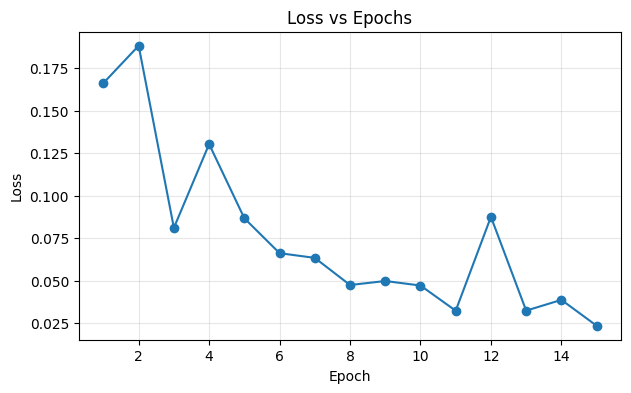

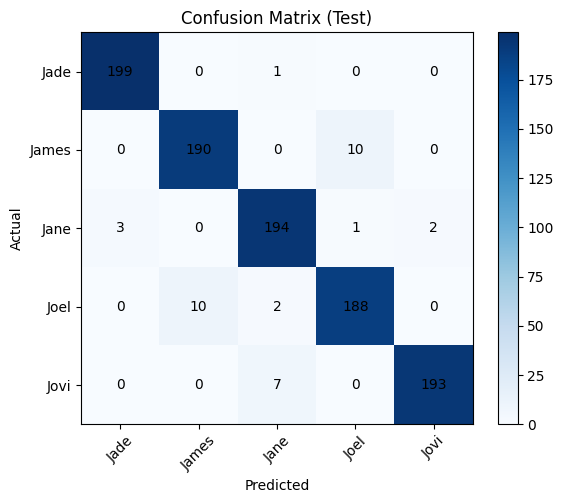

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(h) + 1), h, marker="o")
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix ({cm_nm})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(cls)), cls, rotation=45)
plt.yticks(range(len(cls)), cls)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar()
plt.tight_layout()
plt.show()

## 8. Test Predictions

In [9]:
if Xt.shape[0] == 0:
    print("No test images found in Test/.")
else:
    yn = [cls[i] for i in ytp]
    print("test samples:", len(te_f))
    for f, n in zip(te_f, yn):
        print(f, "->", n)

test samples: 1000
Jade/-601.png -> Jade
Jade/-602.png -> Jade
Jade/-603.png -> Jade
Jade/-604.png -> Jade
Jade/-605.png -> Jade
Jade/-606.png -> Jade
Jade/-607.png -> Jade
Jade/-608.png -> Jade
Jade/-609.png -> Jade
Jade/-610.png -> Jade
Jade/-611.png -> Jade
Jade/-612.png -> Jade
Jade/-613.png -> Jade
Jade/-614.png -> Jade
Jade/-615.png -> Jade
Jade/-616.png -> Jade
Jade/-617.png -> Jade
Jade/-618.png -> Jade
Jade/-619.png -> Jade
Jade/-620.png -> Jade
Jade/-621.png -> Jade
Jade/-622.png -> Jade
Jade/-623.png -> Jade
Jade/-624.png -> Jade
Jade/-625.png -> Jade
Jade/-626.png -> Jade
Jade/-627.png -> Jade
Jade/-628.png -> Jade
Jade/-629.png -> Jade
Jade/-630.png -> Jade
Jade/-631.png -> Jade
Jade/-632.png -> Jade
Jade/-633.png -> Jade
Jade/-634.png -> Jade
Jade/-635.png -> Jade
Jade/-636.png -> Jade
Jade/-637.png -> Jade
Jade/-638.png -> Jade
Jade/-639.png -> Jade
Jade/-640.png -> Jade
Jade/-641.png -> Jade
Jade/-642.png -> Jade
Jade/-643.png -> Jade
Jade/-644.png -> Jade
Jade/-645.png